In [1]:
# Cell 1: Import thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_style("whitegrid")

In [2]:
# Cell 2: Đọc dữ liệu sạch
file_path = "../data/processed/telco_churn_clean.csv"
df = pd.read_csv(file_path)

print("Kích thước dữ liệu sạch:", df.shape)
display(df.head())

Kích thước dữ liệu sạch: (7032, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Cell 3: Thông tin dữ liệu
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 


In [4]:
# Cell 4: Phân loại biến
numerical_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
binary_cols = ["SeniorCitizen"]
categorical_cols = [col for col in df.columns if col not in numerical_cols + binary_cols + ["Churn"]]

print("Biến số:", numerical_cols)
print("Biến nhị phân dạng số:", binary_cols)
print("Biến phân loại:", categorical_cols)

Biến số: ['tenure', 'MonthlyCharges', 'TotalCharges']
Biến nhị phân dạng số: ['SeniorCitizen']
Biến phân loại: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [5]:
# Cell 5: Thống kê mô tả biến số
display(df[numerical_cols].describe())

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


In [6]:
# Cell 6: Phân bố biến mục tiêu
print(df["Churn"].value_counts())
print("\nTỷ lệ phần trăm:")
print(df["Churn"].value_counts(normalize=True) * 100)

Churn
No     5163
Yes    1869
Name: count, dtype: int64

Tỷ lệ phần trăm:
Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


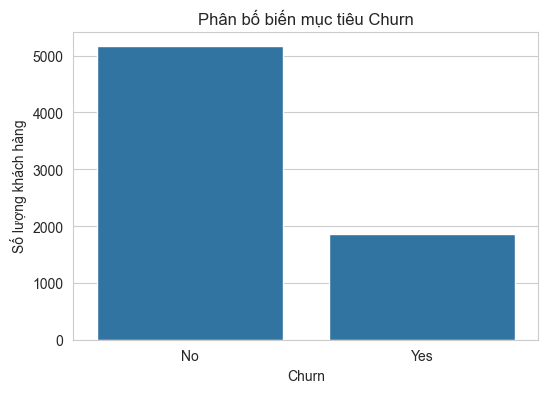

In [7]:
# Cell 7: Biểu đồ phân bố Churn
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Churn")
plt.title("Phân bố biến mục tiêu Churn")
plt.xlabel("Churn")
plt.ylabel("Số lượng khách hàng")
plt.show()

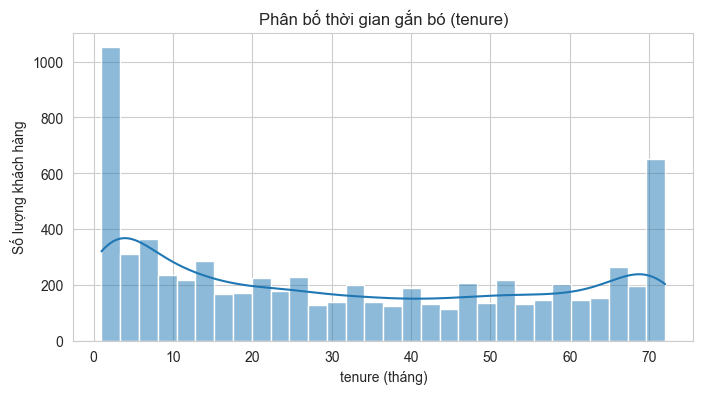

In [8]:
# Cell 8: Phân bố tenure
plt.figure(figsize=(8,4))
sns.histplot(df["tenure"], bins=30, kde=True)
plt.title("Phân bố thời gian gắn bó (tenure)")
plt.xlabel("tenure (tháng)")
plt.ylabel("Số lượng khách hàng")
plt.show()

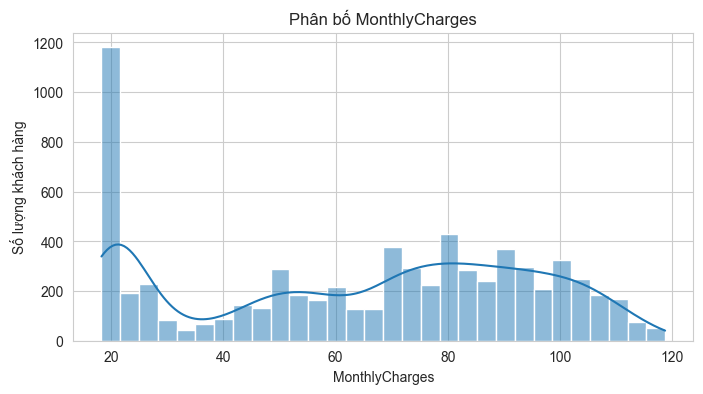

In [9]:
# Cell 9: Phân bố MonthlyCharges
plt.figure(figsize=(8,4))
sns.histplot(df["MonthlyCharges"], bins=30, kde=True)
plt.title("Phân bố MonthlyCharges")
plt.xlabel("MonthlyCharges")
plt.ylabel("Số lượng khách hàng")
plt.show()

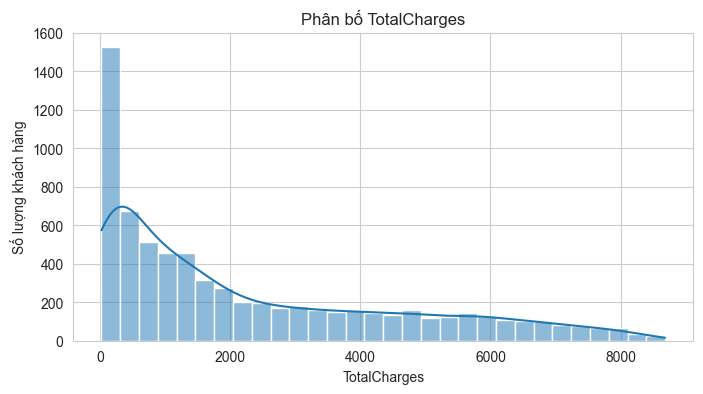

In [10]:
# Cell 10: Phân bố TotalCharges
plt.figure(figsize=(8,4))
sns.histplot(df["TotalCharges"], bins=30, kde=True)
plt.title("Phân bố TotalCharges")
plt.xlabel("TotalCharges")
plt.ylabel("Số lượng khách hàng")
plt.show()

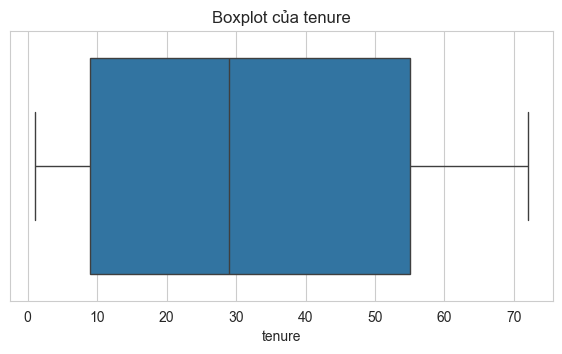

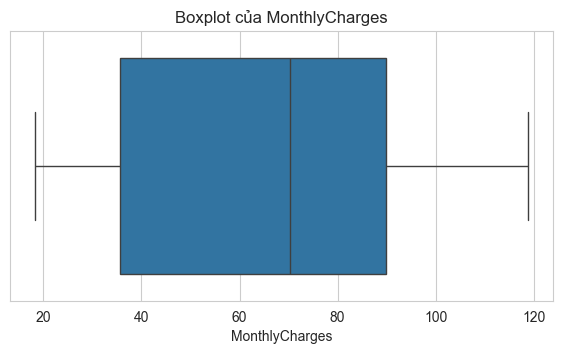

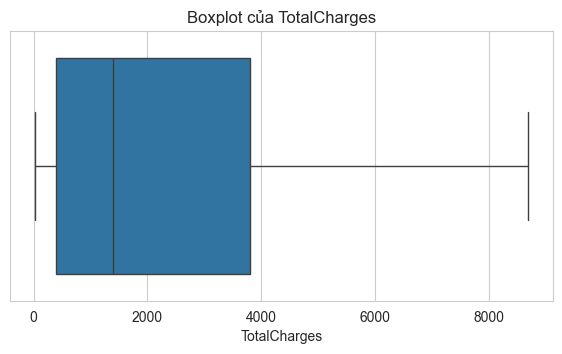

In [11]:
# Cell 11: Boxplot các biến số
for col in numerical_cols:
    plt.figure(figsize=(7,3.5))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot của {col}")
    plt.show()

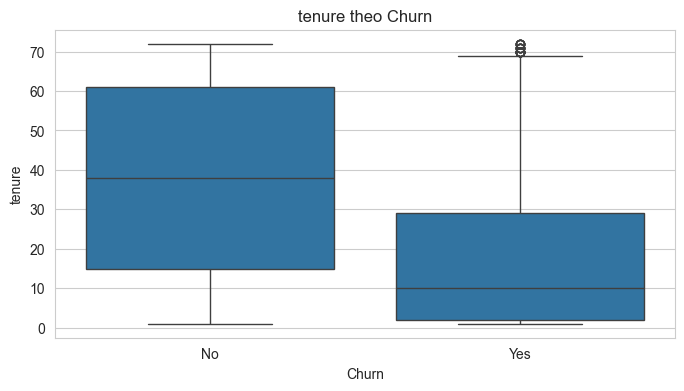

In [12]:
# Cell 12: tenure theo Churn
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x="Churn", y="tenure")
plt.title("tenure theo Churn")
plt.xlabel("Churn")
plt.ylabel("tenure")
plt.show()

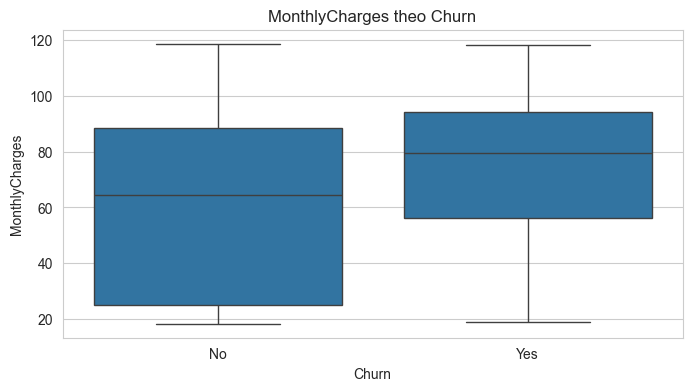

In [13]:
# Cell 13: MonthlyCharges theo Churn
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("MonthlyCharges theo Churn")
plt.xlabel("Churn")
plt.ylabel("MonthlyCharges")
plt.show()

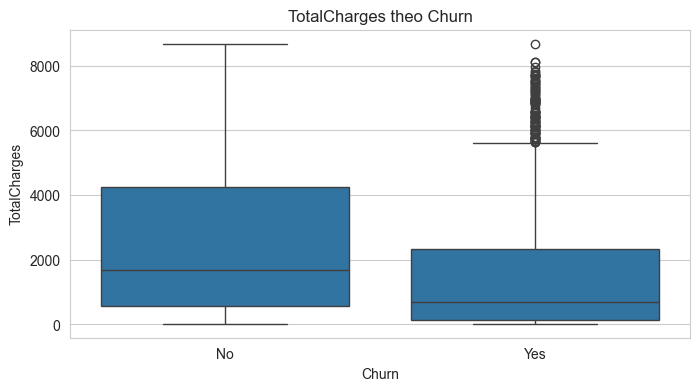

In [14]:
# Cell 14: TotalCharges theo Churn
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x="Churn", y="TotalCharges")
plt.title("TotalCharges theo Churn")
plt.xlabel("Churn")
plt.ylabel("TotalCharges")
plt.show()

In [15]:
# Cell 15: Hàm hỗ trợ vẽ
def plot_count_and_churn_rate(df, col, target="Churn"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    sns.countplot(data=df, x=col, hue=target, ax=axes[0])
    axes[0].set_title(f"{col} theo {target}")
    axes[0].tick_params(axis='x', rotation=30)

    churn_rate = pd.crosstab(df[col], df[target], normalize='index') * 100
    churn_rate["Yes"].sort_values(ascending=False).plot(kind="bar", ax=axes[1])
    axes[1].set_title(f"Tỷ lệ churn theo {col}")
    axes[1].set_ylabel("Tỷ lệ churn (%)")
    axes[1].tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.show()

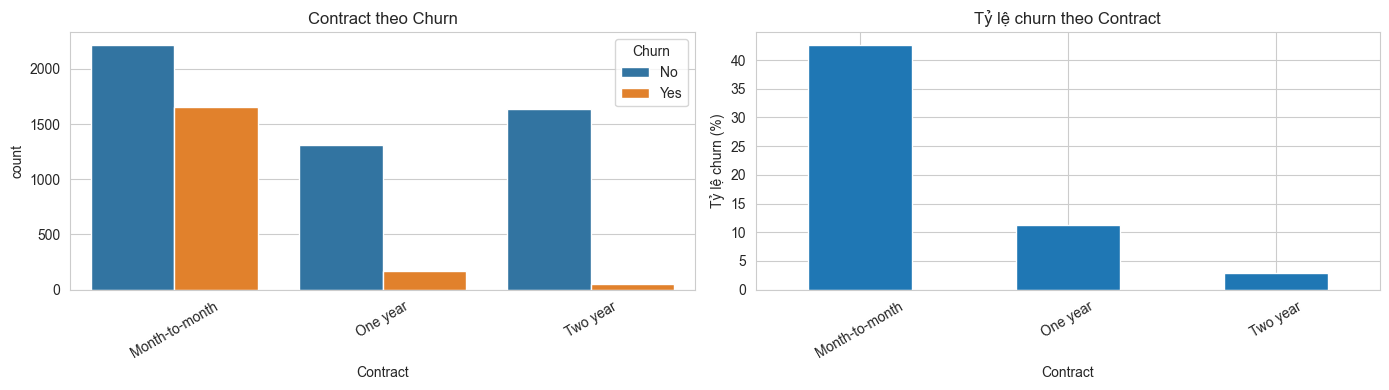

In [16]:
# Cell 16: Churn theo Contract
plot_count_and_churn_rate(df, "Contract")

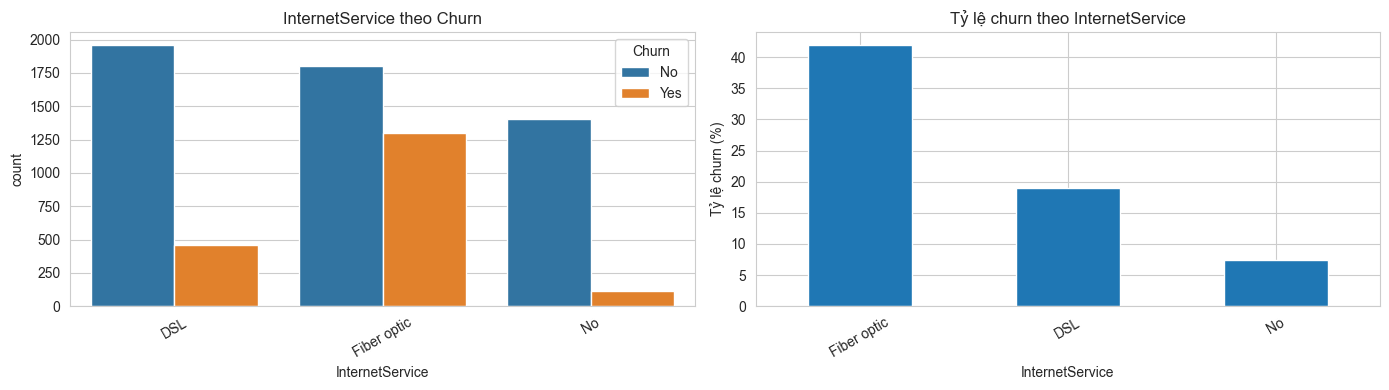

In [17]:
# Cell 17: Churn theo InternetService
plot_count_and_churn_rate(df, "InternetService")

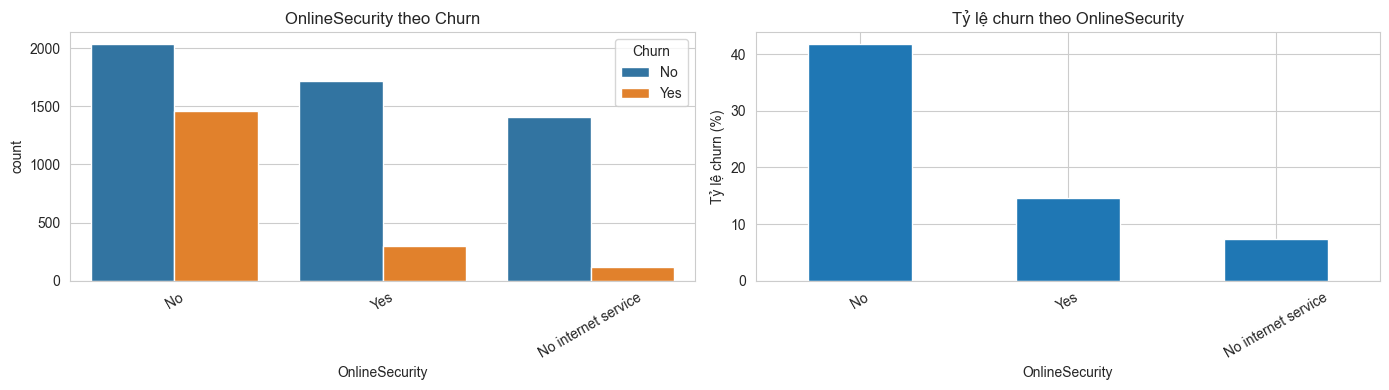

In [18]:
# Cell 18: Churn theo OnlineSecurity
plot_count_and_churn_rate(df, "OnlineSecurity")

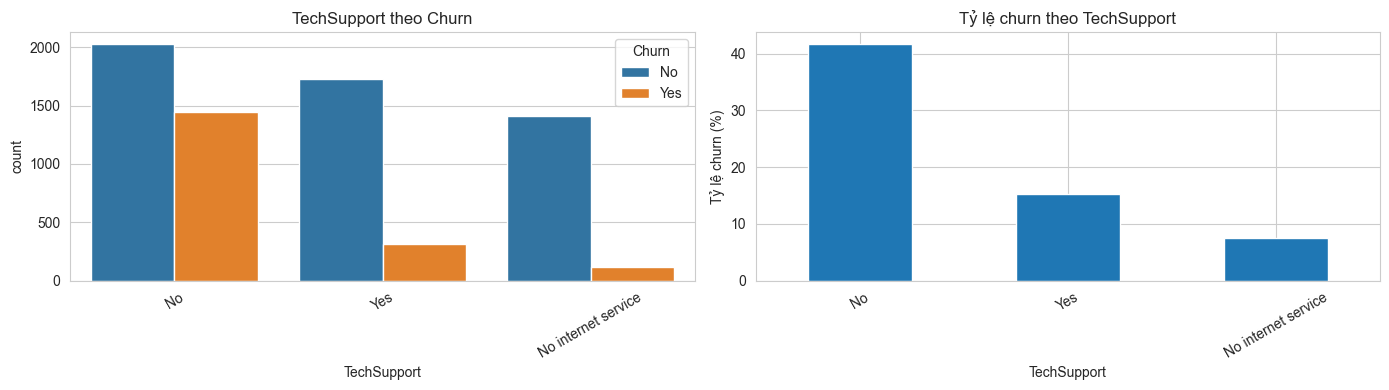

In [19]:
# Cell 19: Churn theo TechSupport
plot_count_and_churn_rate(df, "TechSupport")

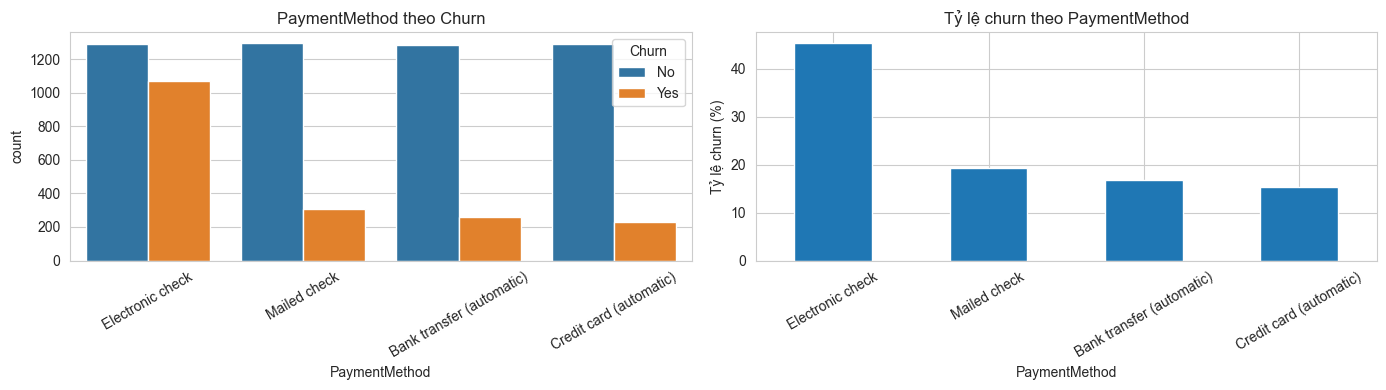

In [20]:
# Cell 20: Churn theo PaymentMethod
plot_count_and_churn_rate(df, "PaymentMethod")

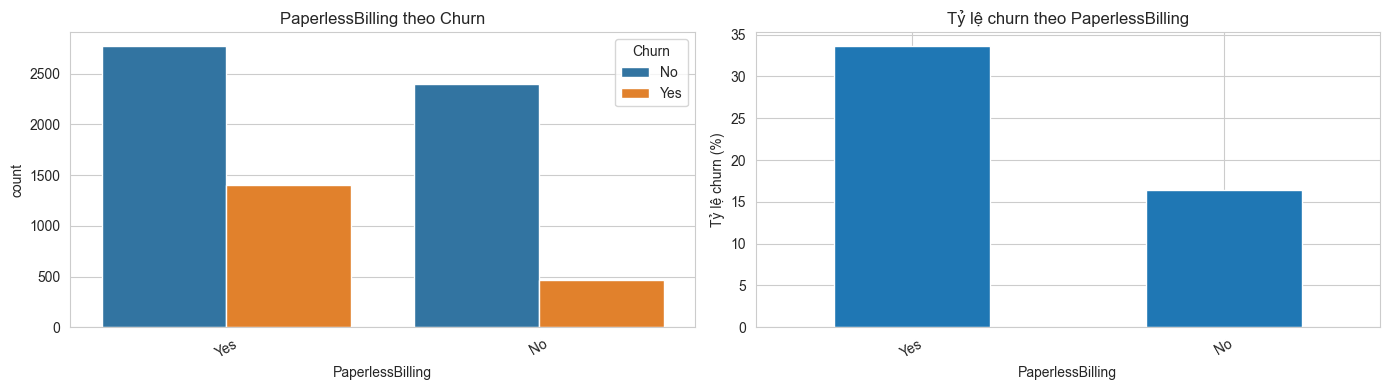

In [21]:
# Cell 21: Churn theo PaperlessBilling
plot_count_and_churn_rate(df, "PaperlessBilling")

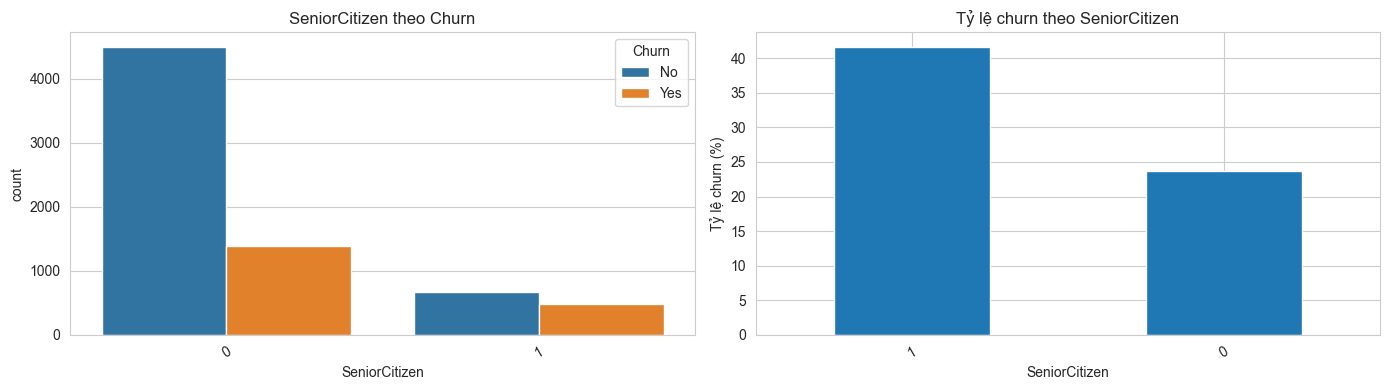

In [22]:
# Cell 22: Churn theo SeniorCitizen
plot_count_and_churn_rate(df, "SeniorCitizen")

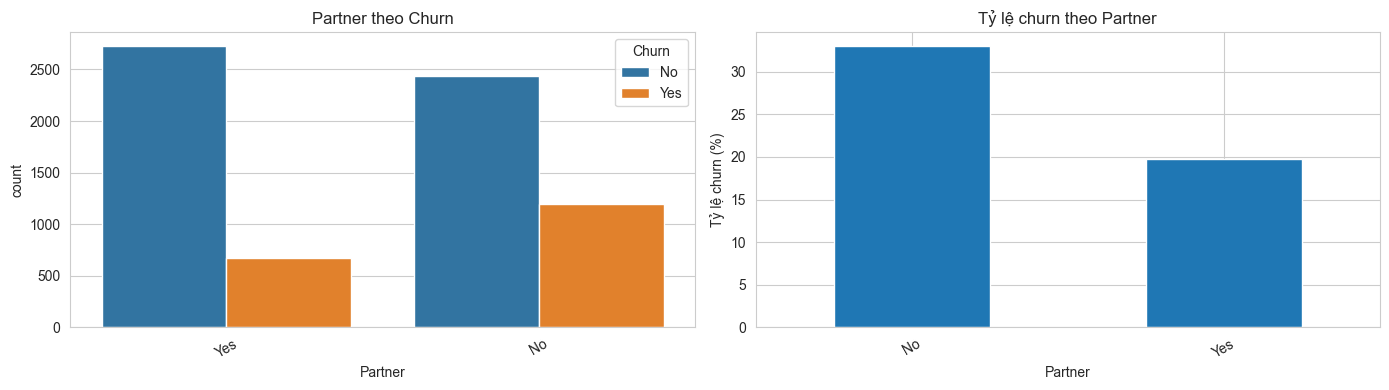

In [23]:
# Cell 23: Churn theo Partner
plot_count_and_churn_rate(df, "Partner")

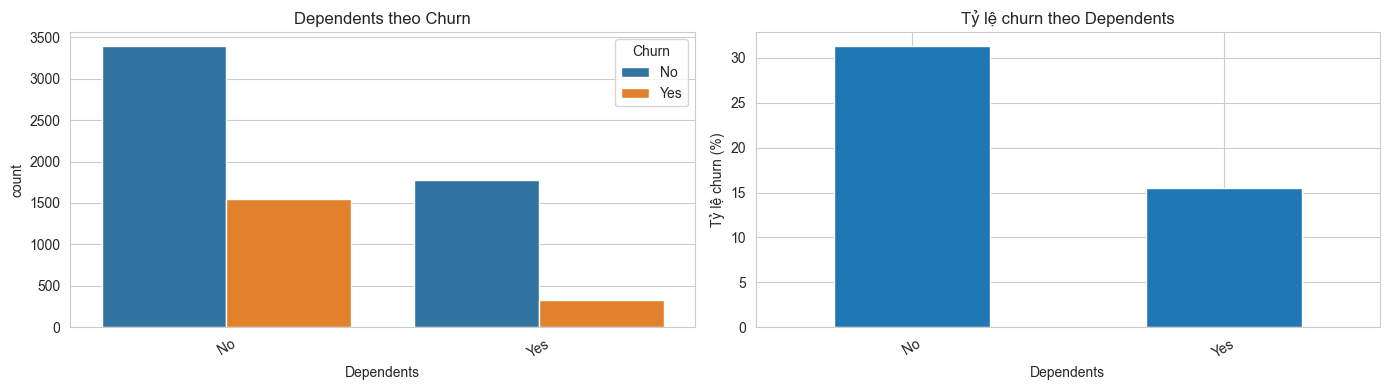

In [24]:
# Cell 24: Churn theo Dependents
plot_count_and_churn_rate(df, "Dependents")

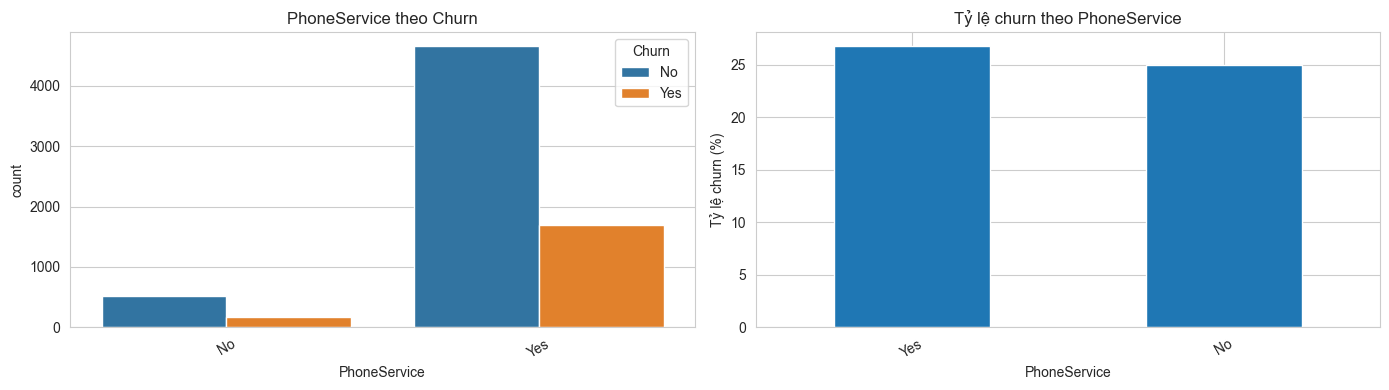

In [25]:
# Cell 25: Churn theo PhoneService
plot_count_and_churn_rate(df, "PhoneService")

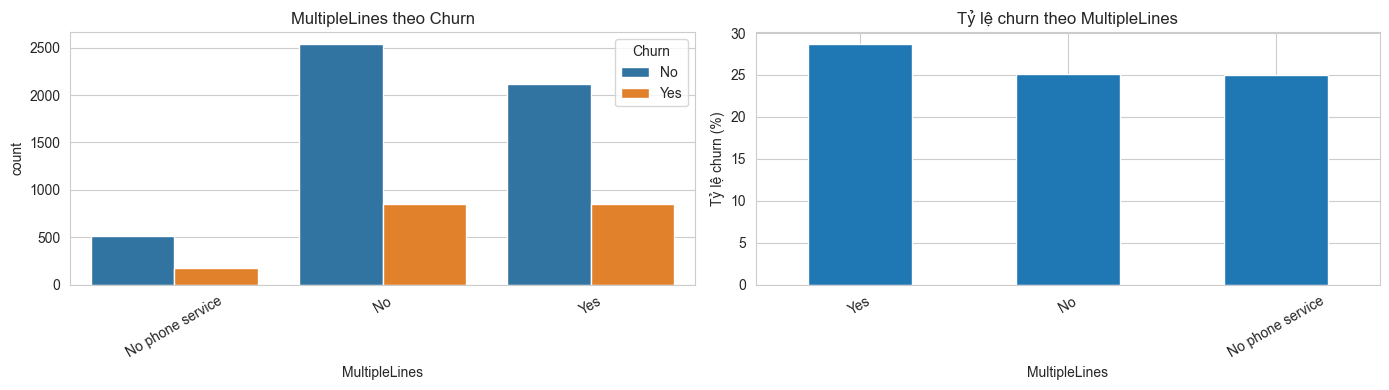

In [26]:
# Cell 26: Churn theo MultipleLines
plot_count_and_churn_rate(df, "MultipleLines")

In [27]:
# Cell 27: Encode tạm để vẽ correlation
df_corr = df.copy()

for col in df_corr.columns:
    if df_corr[col].dtype == "object":
        df_corr[col] = df_corr[col].astype("category").cat.codes

corr_matrix = df_corr.corr()

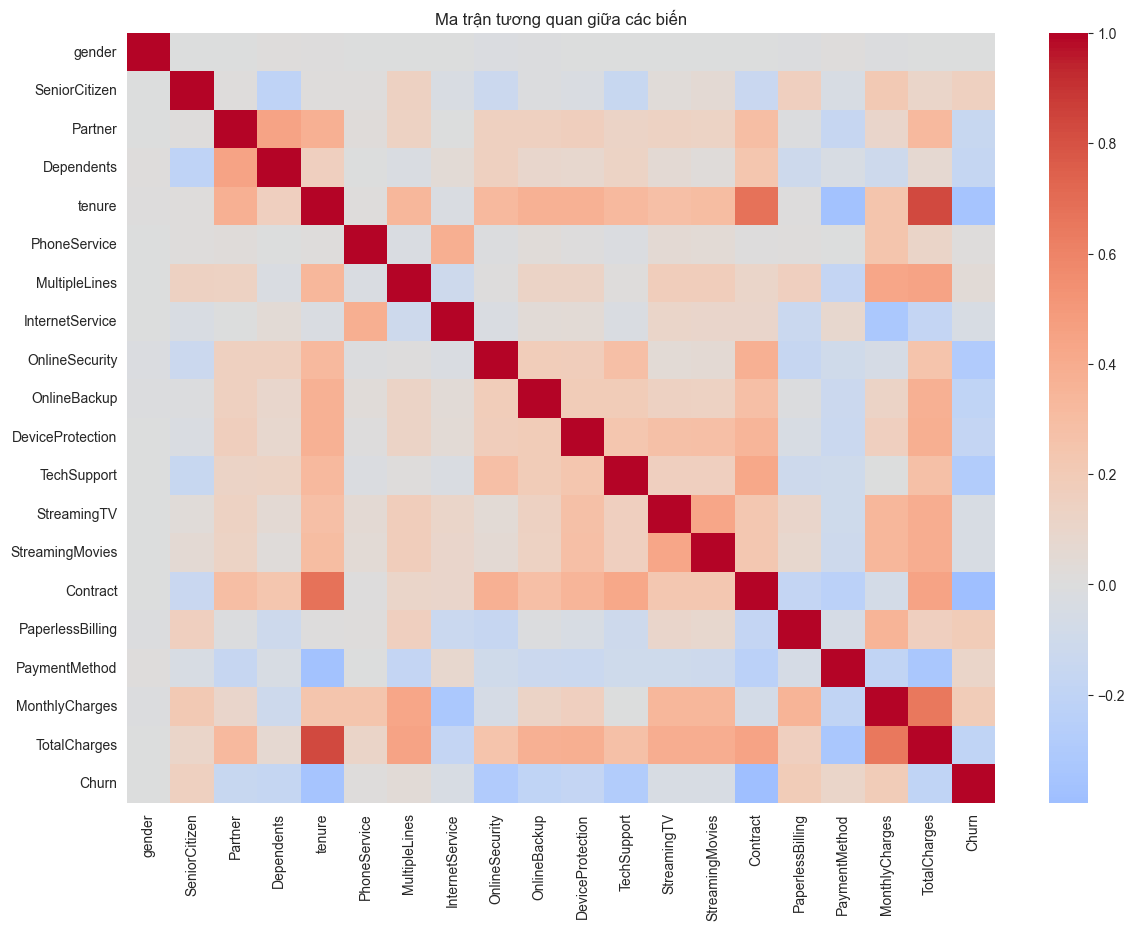

In [28]:
# Cell 28: Heatmap tương quan
plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Ma trận tương quan giữa các biến")
plt.show()

In [29]:
# Cell 29: Hàm tính churn rate
def churn_rate_table(df, col):
    table = pd.crosstab(df[col], df["Churn"], normalize="index") * 100
    table = table.rename(columns={"No": "No_%", "Yes": "Yes_%"})
    return table.sort_values(by="Yes_%", ascending=False)

display(churn_rate_table(df, "Contract"))
display(churn_rate_table(df, "InternetService"))
display(churn_rate_table(df, "OnlineSecurity"))
display(churn_rate_table(df, "TechSupport"))
display(churn_rate_table(df, "PaymentMethod"))

Churn,No_%,Yes_%
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


Churn,No_%,Yes_%
InternetService,,
Fiber optic,58.107235,41.892765
DSL,81.001656,18.998344
No,92.565789,7.434211


Churn,No_%,Yes_%
OnlineSecurity,,
No,58.221333,41.778667
Yes,85.359801,14.640199
No internet service,92.565789,7.434211


Churn,No_%,Yes_%
TechSupport,,
No,58.352535,41.647465
Yes,84.803922,15.196078
No internet service,92.565789,7.434211


Churn,No_%,Yes_%
PaymentMethod,,
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
